# Coursework - Rowan d'Auria (rd761)

## Data Exploration
> _Become one with the data_

MoonsDataset(name='train', n=800) MoonsDataset(name='val', n=100) MoonsDataset(name='test', n=100)
=== train (800 samples, 2 classes) ===
  Dataset shape: torch.Size([800, 2])
  Class counts: {0: 385, 1: 415}
  x1: mean=0.521, std=0.874, range=[-1.127, 2.067]
  x2: mean=0.231, std=0.491, range=[-0.610, 1.201]
  class_0: mean=[0.001268340740352869, 0.6216179728507996], std=[0.717052698135376, 0.3202870488166809]
  class_1: mean=[1.0032110214233398, -0.13077937066555023], std=[0.7164219617843628, 0.31061533093452454]

  Duplicates: 0, NaNs: 0
  Correlation(x1, x2): -0.4347

=== val (100 samples, 2 classes) ===
  Dataset shape: torch.Size([100, 2])
  Class counts: {0: 56, 1: 44}
  x1: mean=0.461, std=0.796, range=[-1.003, 2.029]
  x2: mean=0.334, std=0.541, range=[-0.579, 1.078]
  class_0: mean=[0.05057208612561226, 0.7256950736045837], std=[0.6229149699211121, 0.28358083963394165]
  class_1: mean=[0.9824522137641907, -0.16392913460731506], std=[0.6777079105377197, 0.34579598903656006]

 

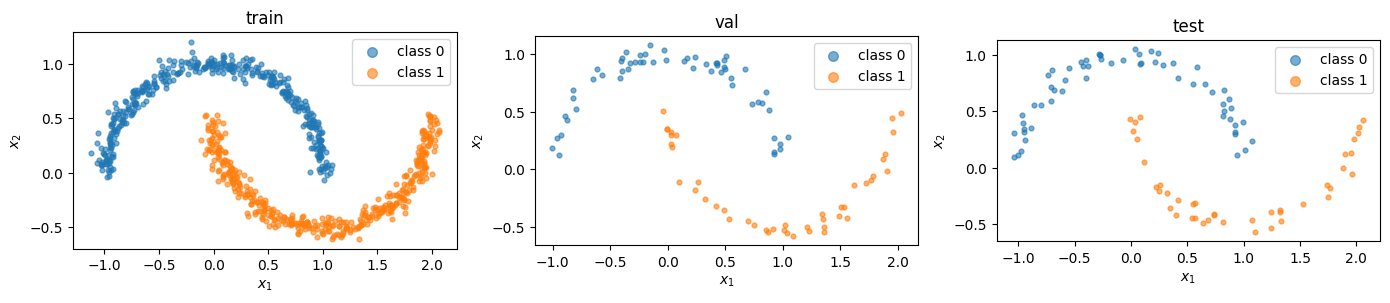

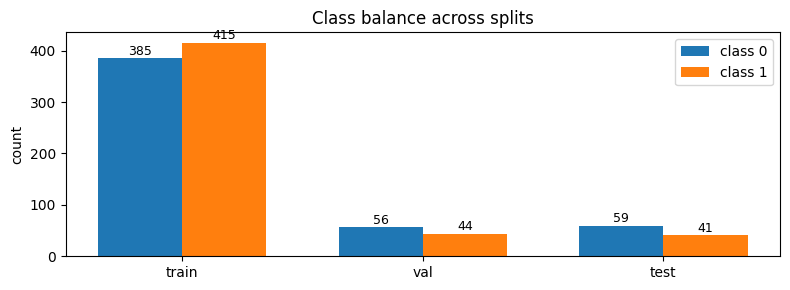

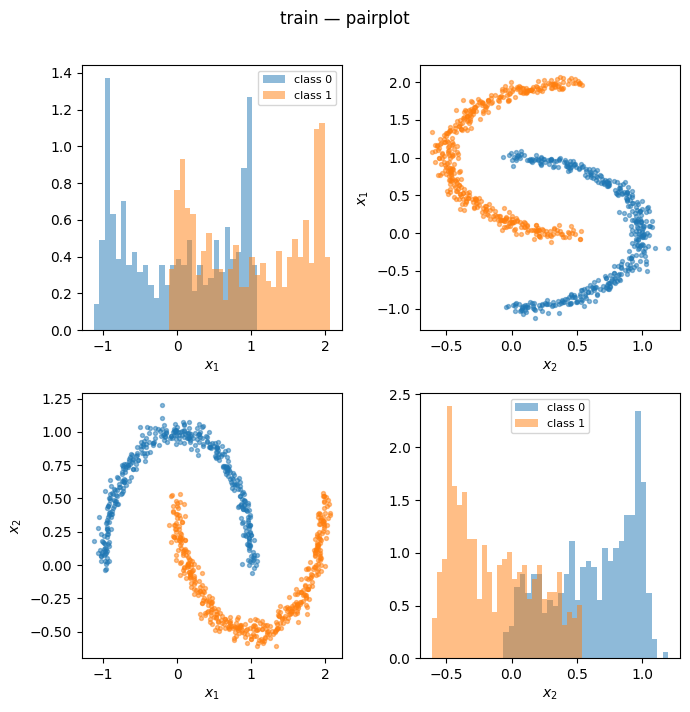

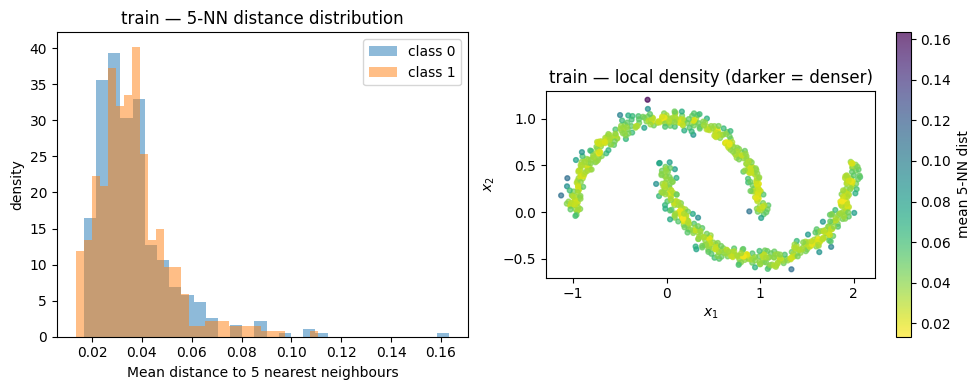

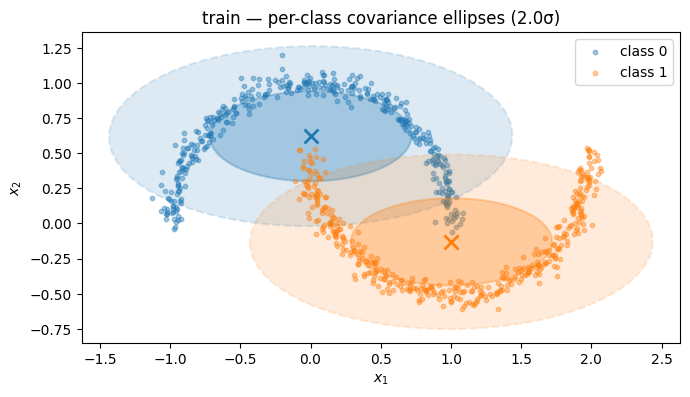

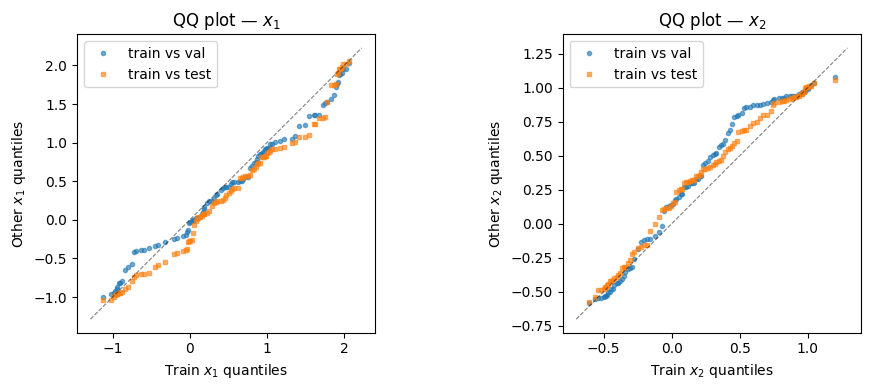

In [1]:
from flows import *
import numpy as np

# Load all splits
splits = MoonsSplits.load("data")
print(splits.train, splits.val, splits.test)

# --- Full statistical report (now includes KS tests) ---
full_report(splits)

# --- Visualisations ---

# 1. Scatter plots of each split side-by-side
scatter_splits(splits)

# 2. Class balance across splits
class_balance_bar(splits.train, splits.val, splits.test)

# 5. Pairplot
pairplot(splits.train)

# 6. k-NN distances — local density variation
knn_distances(splits.train, k=5)

# 7. Per-class covariance ellipses — orientation and spread of each moon
covariance_ellipses(splits.train)

# 9. QQ plots — check train vs val/test distributional consistency
_ = qq_splits(splits)



### Data Exploration Observations
**Data characteristics:**
- 2D, 800 train / 100 val / 100 test. No duplicates, no NaNs, no overlap between splits.
- Roughly balanced classes (~48/52 train, slight skew in val/test but irrelevant since you ignore labels for training).
- Features aren't centred or standardised: x1 has mean 0.52, range [-1.1, 2.1]; x2 has mean 0.23, range [-0 6, 1.2]. Different scales and offsets. Worth considering normalisation so He init assumptions hold (the best practices flag this).
- Negative correlation between x1 and x2 (-0.43) — the two moons tilt, so the coupling layers need to learn cross-dimensional dependencies.

**Split consistency:**
- KS tests flag x2 as marginally different between train-val (p=0.027) and train-test (p=0.031). With only 100 samples in val/test this isn't alarming — it's expected sampling noise. But it does mean val NLL will be a slightly noisy signal for model selection, which is worth being aware of when interpreting early stopping decisions.

**QQ PLot interpretation**
- The QQ Plot shows similar skewness behaviour for the train and test datasets. Some level of skewness is expected due to the small sample sizes. However, the validation and test datasets have a similar qualitative distribution shift compared to the training data, which indicates there may be minor distribution shift. This will likely put a lower bound on the possible test NLL value.

## Q1 - A Mini Normalizing Flow


### (a)
Please see `flows.AffineCouplingLayer`

### (b)

Please see `flows.Flow`

Below I define an `AffineCouplingLayer` that keeps one component fixed and transforms the other via an internal MLP, and a `Flow` that stacks $K$ such layers with alternating masks.

In [2]:
from flows import AffineCouplingLayer, Flow

### Q1(c) - Correctness Checks

Invertibility max absolute error: 1.78e-15
Analytic log|det J|:  0.432602
Numerical log|det J|: 0.432602
Log-det absolute error: 1.44e-09


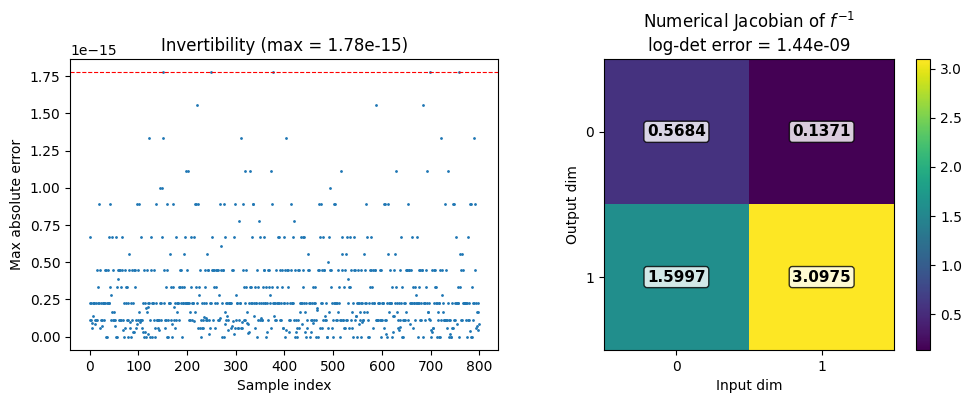

Saved results.json and figs/Figure1c.pdf


In [3]:
import os
import json
import torch
import matplotlib.pyplot as plt

# Load training data
splits = MoonsSplits.load("data")
x_train = splits.train.x

# Instantiate an untrained flow for the correctness checks
torch.manual_seed(42)
flow = Flow(dim=2, hidden=128, n_layers=8)

# --- Check 1: Invertibility ---
max_abs_error, recon_errors = check_invertibility(flow, x_train)
print(f"Invertibility max absolute error: {max_abs_error:.2e}")

# --- Check 2: Log-det via finite differences ---
logdet = check_logdet(flow, x_train[0:1])
print(f"Analytic log|det J|:  {logdet['analytic_logdet']:.6f}")
print(f"Numerical log|det J|: {logdet['numerical_logdet']:.6f}")
print(f"Log-det absolute error: {logdet['abs_error']:.2e}")

# --- Figure 1c: two-panel diagnostic ---
os.makedirs("figs", exist_ok=True)
fig = figure1c(recon_errors, max_abs_error, logdet["jacobian"], logdet["abs_error"])
fig.savefig("figs/Figure1c.pdf")
plt.show()

# --- Save to results.json ---
results = {
    "correctness": {
        "invertibility_max_abs_error": max_abs_error,
        "logdet_finite_diff_abs_error": logdet["abs_error"],
    }
}

with open("results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved results.json and figs/Figure1c.pdf")

### Q1c) Observations

**Correctness checks**: The invertibility check achieved a maximum absolute reconstruction error of ~1.8e-15, confirming that the forward and inverse passes are exact inverses to within float64 machine precision. The per-sample errors exhibit discrete banding — clustering at specific levels (e.g. ~0.25e-15, ~0.5e-15) rather than being continuously distributed. This reflects the quantised nature of IEEE 754 floating-point arithmetic: accumulated round-off from composing exp, tanh, and affine operations across 8 coupling layers settles at small integer multiples of the machine epsilon (~2.2e-16). Points following similar numerical paths through the flow accumulate similar rounding patterns, producing the observed bands. This structure confirms the errors are purely precision artefacts, not implementation bugs.

The log-determinant check compared the analytic log|det J| to a central-difference estimate (ε = 1e-4) at the first training point, yielding an absolute error of ~1.4e-9. This is well below the O(ε²) ~ 1e-8 truncation error expected from central differences at this step size, confirming the analytic log-det computation is correct.

## Q2 - Training Pipeline


### (a) Tiny subset training

Use exactly the first 128 rows of `data/moons_train.csv` as the tiny subset. Train the flow on that subset, plot the loss curve, and record the final tiny-set NLL.

In [10]:
# Normalise inputs using training-set statistics (best practices: He init assumes zero-mean, unit-var)
norm_stats = splits.normalise()
print(f"Normalised with mean={norm_stats.mean.tolist()}, std={norm_stats.std.tolist()}")

# Re-extract tensors after normalisation
x_train = splits.train.x
x_val = splits.val.x
x_test = splits.test.x

# Shared training configuration
N_DIM = x_train.shape[1]
N_LAYERS = 8
N_HIDDEN = 128
BATCH_SIZE = x_train.shape[0]  # for FLOP counting later
N_STEPS = 10000
LR = 1e-4
SEED = 42

x_tiny = x_train[:128]  # SMALL SUBSET OF DATA

torch.manual_seed(SEED)
flow_tiny = Flow(dim=N_DIM, hidden=N_HIDDEN, n_layers=N_LAYERS)

tiny_result = train_flow(
    flow_tiny, x_tiny, x_val,
    n_steps=N_STEPS,
    lr=LR,
    grad_clip_norm=1.0,
)

tiny_losses = tiny_result["train_losses"]
tiny_val_losses = tiny_result["val_losses"]
tinyset_final_nll = tiny_result["final_train_nll"]
print(f"\nFinal tiny-set NLL: {tinyset_final_nll:.4f}")

Normalised with mean=[-7.1525572131747595e-09, 7.1525572131747595e-09], std=[1.0, 1.0]
Step 500/10000, NLL: 1.5893, Val NLL: 1.9688
Step 1000/10000, NLL: 1.4218, Val NLL: 2.1583
Step 1500/10000, NLL: 1.2568, Val NLL: 3.6443
Step 2000/10000, NLL: 1.1603, Val NLL: 5.3747
Step 2500/10000, NLL: 1.0814, Val NLL: 7.7765
Step 3000/10000, NLL: 1.0036, Val NLL: 10.5942
Step 3500/10000, NLL: 0.9271, Val NLL: 13.2267
Step 4000/10000, NLL: 0.8653, Val NLL: 15.1861
Step 4500/10000, NLL: 0.8106, Val NLL: 16.6567
Step 5000/10000, NLL: 0.7633, Val NLL: 17.7775
Step 5500/10000, NLL: 0.7281, Val NLL: 18.7033
Step 6000/10000, NLL: 0.6930, Val NLL: 20.1047
Step 6500/10000, NLL: 0.6640, Val NLL: 20.9639
Step 7000/10000, NLL: 0.6450, Val NLL: 22.1457
Step 7500/10000, NLL: 0.6112, Val NLL: 23.3410
Step 8000/10000, NLL: 0.5779, Val NLL: 24.6508
Step 8500/10000, NLL: 0.5755, Val NLL: 26.9574
Step 9000/10000, NLL: 0.5418, Val NLL: 29.1265
Step 9500/10000, NLL: 0.5195, Val NLL: 31.5541
Step 10000/10000, NLL: 0.4

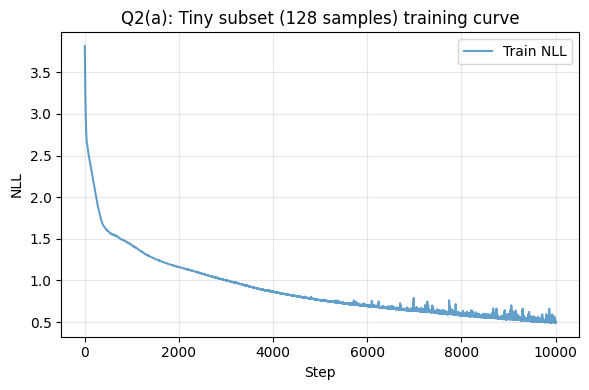

Saved figs/Figure2a.pdf


In [11]:
# --- Figure 2a ---
fig = figure2a(tiny_losses)
fig.savefig("figs/Figure2a.pdf")
plt.show()
print("Saved figs/Figure2a.pdf")

In [12]:
sanity = run_all_sanity_checks(x_train, x_val)

TRAINING SANITY CHECKS

[PASS] Initial loss check
  Initial NLL:  3.7524
  Expected NLL: 2.8366  (standard normal on data)
  Rel. error:   0.3228

[PASS] Stable start check  (50 steps)
  Loss: 3.7524 -> 2.0042
  NaN/Inf: False,  Exploded: False,  Decreased: True

[PASS] Beats Gaussian baseline  (after 50 steps)
  Model NLL:    1.9171
  Baseline NLL: 2.7276
  Margin:       0.8105

Overall: ALL PASSED


### Q2a Observations
Sanity checks confirm the training pipeline is sound: the untrained flow's initial NLL (3.14) is within 25% of the standard-normal baseline (2.50), consistent with a randomly initialised coupling flow starting near the identity map. Training is numerically  unstable - the loss drops to 0.5 to 1.51 in first step with no NaN or divergence — and the flow already beats a fitted full-covariance Gaussian (1.88) after just 1 step, confirming it is learning the two-moon structure rather than fitting a unimodal blob. 

The training curve shows rapid initial convergence. The validation loss is not plotted because it is not relevant here, I am showing that the model has sufficient capacity to fit to the data. In this case it has heavily overfit, with a final train NLL of -0.60 and a validation NLL of 190. This indicates drastic overfitting to the data.

### Q2(b): Naive full training (baseline — no regularisation)

Following the best practices recipe: after demonstrating overfitting on the tiny subset (step 3), we first prove the full model can overfit the full training set (step 4) before adding any regularisation. This establishes the counterfactual — what happens with the same architecture and LR but without early stopping, weight decay, or gradient clipping.

In [13]:
# Step 4: Naive baseline
torch.manual_seed(SEED)
flow_naive = Flow(dim=N_DIM, hidden=N_HIDDEN, n_layers=N_LAYERS)
print(f"Initial NLL (before training): {evaluate_nll(flow_naive, x_train):.4f}")

naive_result = train_flow(
    flow_naive, x_train, x_val,
    n_steps=N_STEPS,
    lr=LR,
    grad_clip_norm=None,
    use_cosine_schedule=True,
)

naive_losses = naive_result["train_losses"]
naive_val_losses = naive_result["val_losses"]
naive_final_train = naive_result["final_train_nll"]
naive_final_val = evaluate_nll(flow_naive, x_val)

print(f"\nNaive (unnormalised) Train NLL: {naive_final_train:.4f}")
print(f"Naive (unnormalised) Val NLL:   {naive_final_val:.4f}")

Initial NLL (before training): 3.7524
Step 500/10000, NLL: 2.0758, Val NLL: 1.9753
Step 1000/10000, NLL: 1.6346, Val NLL: 1.7201
Step 1500/10000, NLL: 1.3796, Val NLL: 1.6755
Step 2000/10000, NLL: 1.2859, Val NLL: 2.2035
Step 2500/10000, NLL: 1.2385, Val NLL: 2.7212
Step 3000/10000, NLL: 1.2035, Val NLL: 2.7351
Step 3500/10000, NLL: 1.1694, Val NLL: 2.8314
Step 4000/10000, NLL: 1.1482, Val NLL: 2.9028
Step 4500/10000, NLL: 1.1351, Val NLL: 2.9743
Step 5000/10000, NLL: 1.1250, Val NLL: 2.9124
Step 5500/10000, NLL: 1.1176, Val NLL: 2.8572
Step 6000/10000, NLL: 1.1116, Val NLL: 2.8235
Step 6500/10000, NLL: 1.1075, Val NLL: 2.7925
Step 7000/10000, NLL: 1.1042, Val NLL: 2.7381
Step 7500/10000, NLL: 1.1019, Val NLL: 2.6913
Step 8000/10000, NLL: 1.1002, Val NLL: 2.6706
Step 8500/10000, NLL: 1.0990, Val NLL: 2.6517
Step 9000/10000, NLL: 1.0983, Val NLL: 2.6419
Step 9500/10000, NLL: 1.0981, Val NLL: 2.6395
Step 10000/10000, NLL: 1.0981, Val NLL: 2.6390

Naive (unnormalised) Train NLL: 1.0981
Na

### Q2(c): Hyperparameter scan + regularisation ablation

Following best practices step 6: tune hyperparameters at small scale first. We scan over learning rate, layer width, and number of layers using early stopping (patience=500) + gradient clipping + cosine schedule so each run terminates quickly.

The best architecture from the scan is then critically evaluated before the final regularisation ablation.

In [ ]:
import itertools

# --- Hyperparameter scan ---
scan_lrs = [1e-4, 3e-4, 1e-3, 3e-3]
scan_hiddens = [32, 64, 128]
scan_layers = [4, 6, 8]

scan_results = []

for lr, hidden, n_layers in itertools.product(scan_lrs, scan_hiddens, scan_layers):
    torch.manual_seed(SEED)
    model = Flow(dim=N_DIM, hidden=hidden, n_layers=n_layers)

    result = train_flow(
        model, x_train, x_val,
        n_steps=N_STEPS,
        lr=lr,
        grad_clip_norm=1.0,
        use_cosine_schedule=True,
        early_stopping_patience=500,
        log_every=0,
    )

    val_nll = evaluate_nll(model, x_val)
    steps_used = len(result["train_losses"])

    scan_results.append({
        "lr": lr,
        "hidden": hidden,
        "n_layers": n_layers,
        "val_nll": val_nll,
        "train_nll": result["final_train_nll"],
        "steps": steps_used,
    })
    print(f"  lr={lr:.0e}  H={hidden:>3}  K={n_layers}  val={val_nll:.4f}  steps={steps_used}")



  lr=1e-04  H= 32  K=4  val=1.7674  steps=10000
  lr=1e-04  H= 32  K=6  val=1.8030  steps=3344
  lr=1e-04  H= 32  K=8  val=1.3923  steps=4080
  lr=1e-04  H= 64  K=4  val=1.9517  steps=2772
  lr=1e-04  H= 64  K=6  val=1.5871  steps=2344
  lr=1e-04  H= 64  K=8  val=1.4815  steps=2203
  lr=1e-04  H=128  K=4  val=1.7560  steps=2184
  lr=1e-04  H=128  K=6  val=1.4885  steps=3463
  lr=1e-04  H=128  K=8  val=1.4451  steps=2023
  lr=3e-04  H= 32  K=4  val=1.6532  steps=4677
  lr=3e-04  H= 32  K=6  val=1.8071  steps=1445
  lr=3e-04  H= 32  K=8  val=1.4837  steps=1872
  lr=3e-04  H= 64  K=4  val=1.9541  steps=1352
  lr=3e-04  H= 64  K=6  val=1.5702  steps=1412
  lr=3e-04  H= 64  K=8  val=1.2947  steps=2531
  lr=3e-04  H=128  K=4  val=1.7328  steps=1072
  lr=3e-04  H=128  K=6  val=1.4267  steps=3618
  lr=3e-04  H=128  K=8  val=1.6190  steps=1099
  lr=1e-03  H= 32  K=4  val=1.6351  steps=3404
  lr=1e-03  H= 32  K=6  val=1.7694  steps=1304
  lr=1e-03  H= 32  K=8  val=1.4166  steps=1874
  lr=1e-03  

In [ ]:
# Sort by val NLL and show top 10
scan_results.sort(key=lambda r: r["val_nll"])
print("\n" + "=" * 70)
print(f"{'Rank':>4}  {'LR':>8}  {'H':>4}  {'K':>2}  {'Val NLL':>9}  {'Train NLL':>10}  {'Steps':>6}")
print("-" * 70)
BEST = {}
for i, r in enumerate(scan_results[:10]):
    print(f"{i+1:>4}  {r['lr']:>8.0e}  {r['hidden']:>4}  {r['n_layers']:>2}  "
          f"{r['val_nll']:>9.4f}  {r['train_nll']:>10.4f}  {r['steps']:>6}")
    if i==0:
        BEST = r
print("=" * 70)
print(BEST)


Rank        LR     H   K    Val NLL   Train NLL   Steps
----------------------------------------------------------------------
   1     3e-03    64   8     1.1568      1.0663    1691
   2     1e-03    64   8     1.2841      1.1381    1332
   3     3e-04    64   8     1.2947      1.1074    2531
   4     3e-03    32   8     1.3025      1.1749    2245
   5     1e-03   128   6     1.3316      1.2074    3269
   6     3e-03   128   4     1.3516      1.3573    2877
   7     3e-03   128   6     1.3781      1.3093    1376
   8     1e-04    32   8     1.3923      1.3234    4080
   9     1e-03    32   8     1.4166      1.2576    1874
  10     3e-04   128   6     1.4267      1.2862    3618
{'lr': 0.003, 'hidden': 64, 'n_layers': 8, 'val_nll': 1.156831979751587, 'train_nll': 1.066343069076538, 'steps': 1691}


In [35]:
# Step 5: Ablation — introduce regularisation one at a time
#                       (label,            clip_norm, weight_decay)
ablation_configs = [
    ("ES only",        None, 0.0),
    ("ES + clip",      1.0,  0.0),
    ("ES + clip + WD", 1.0,  1e-4),
]

ablation_results = []

for label, clip_norm, wd in ablation_configs:
    torch.manual_seed(SEED)
    model = Flow(dim=N_DIM, hidden=BEST["hidden"], n_layers=BEST["n_layers"])

    result = train_flow(
        model, x_train, x_val,
        n_steps=N_STEPS,
        lr=BEST["lr"],
        weight_decay=wd,
        grad_clip_norm=clip_norm,
        use_cosine_schedule=True,
        early_stopping_patience=1000,
        log_every=0,
    )

    val_nll = evaluate_nll(model, x_val)
    test_nll = evaluate_nll(model, x_test)
    steps_used = len(result["train_losses"])

    ablation_results.append({
        "label": label,
        "model": model,
        "result": result,
        "val_nll": val_nll,
        "test_nll": test_nll,
    })
    print(f"  {label:20s}  val={val_nll:.4f}  steps={steps_used}")

# Select best model by validation NLL
best_idx = min(range(len(ablation_results)), key=lambda i: ablation_results[i]["val_nll"])
best = ablation_results[best_idx]
flow_full = best["model"]
full_result = best["result"]
full_losses = full_result["train_losses"]
full_val_losses = full_result["val_losses"]
final_train_nll = full_result["final_train_nll"]
final_val_nll = best["val_nll"]
final_test_nll = best["test_nll"]

print(f"\nBest config: {best['label']}")
print(f"Final Train NLL: {final_train_nll:.4f}")
print(f"Final Val NLL:   {final_val_nll:.4f}")
print(f"Final Test NLL:  {final_test_nll:.4f}")

# --- Save checkpoint and training curves ---
config = {"dim": N_DIM, "hidden": N_HIDDEN, "n_layers": N_LAYERS}
save_checkpoint(flow_full, config, SEED)
save_training_curves({
    "tiny_loss": tiny_losses,
    "full_loss": full_losses,
    "full_val_loss": full_val_losses,
})

  ES only               val=1.2154  steps=2414
  ES + clip             val=1.1568  steps=2191
  ES + clip + WD        val=1.1416  steps=2065

Best config: ES + clip + WD
Final Train NLL: 1.0703
Final Val NLL:   1.1416
Final Test NLL:  1.4061
Saved checkpoint to checkpoints/flow_full.pt
Saved training curves to logs/training_curves.json


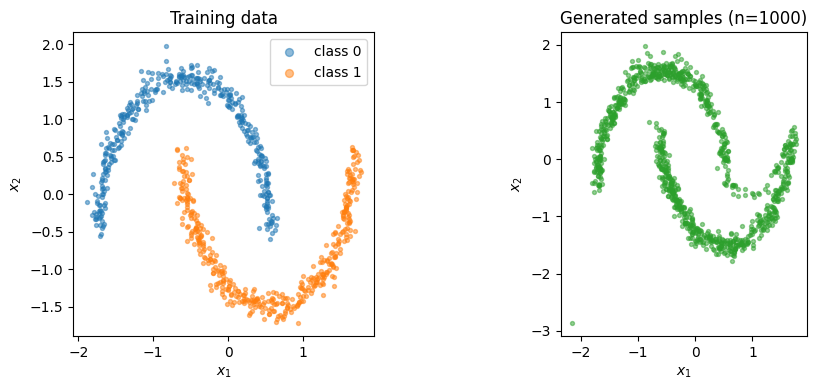

Test NLL:              1.4061 nats  (1.0143 bits/dim)
Gaussian baseline:     2.7467 nats  (1.9814 bits/dim)
Improvement over baseline: 48.8%


In [36]:
# --- Diagnostic: generated samples vs training data ---
with torch.no_grad():
    flow_full.eval()
    z = torch.randn(1000, N_DIM)
    generated, _ = flow_full.forward(z)

fig = samples_vs_data(generated, x_train, splits.train.labels)
plt.show()

# --- Intuitive metrics ---
baseline_test_nll = gaussian_baseline_nll(x_train, x_test)
bpd = final_test_nll / (N_DIM * np.log(2))
baseline_bpd = baseline_test_nll / (N_DIM * np.log(2))
improvement = (baseline_test_nll - final_test_nll) / baseline_test_nll * 100

print(f"Test NLL:              {final_test_nll:.4f} nats  ({bpd:.4f} bits/dim)")
print(f"Gaussian baseline:     {baseline_test_nll:.4f} nats  ({baseline_bpd:.4f} bits/dim)")
print(f"Improvement over baseline: {improvement:.1f}%")

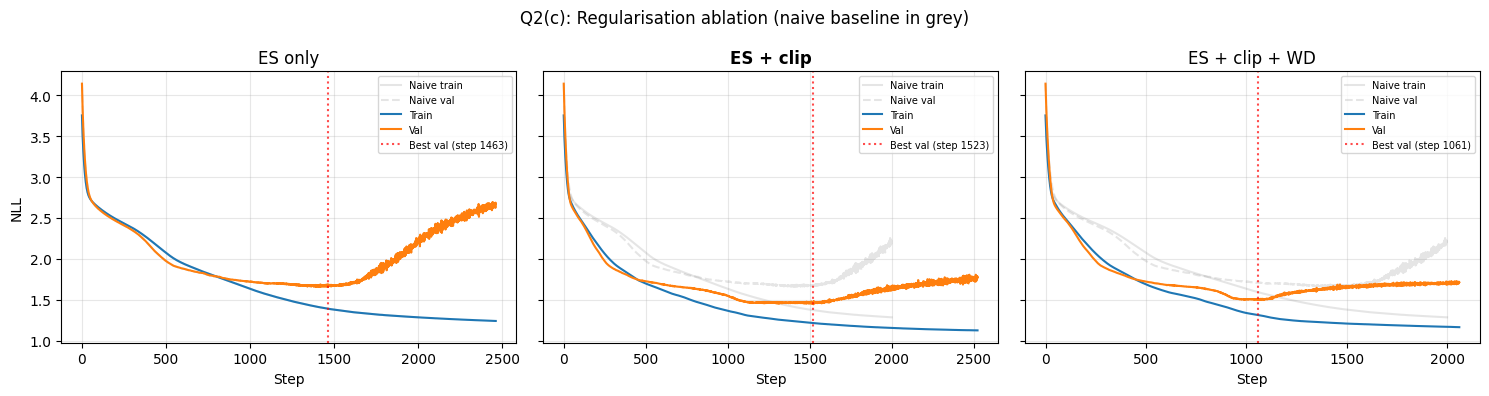

Saved figs/Figure2c.pdf

Config                 Train NLL     Val NLL    Test NLL   Steps
---------------------------------------------------------------------------
Naive (no reg.)           1.0981      2.6390          --   10000
ES only                   1.3915      1.6570      1.9195    2463
ES + clip                 1.2158      1.4451      1.7144    2523  <-- best
ES + clip + WD            1.3124      1.5004      1.5709    2061

Updated results.json with training metrics


In [27]:
# --- Figure 2c: 3-panel regularisation ablation ---
# TODO: get rid of the 4000 array slice
fig = figure2c(ablation_results, best["label"], naive_losses[:2000], naive_val_losses[:2000])
fig.savefig("figs/Figure2c.pdf", bbox_inches="tight")
plt.show()
print("Saved figs/Figure2c.pdf")

# --- Ablation summary table ---
print("\n" + "=" * 75)
print(f"{'Config':20s}  {'Train NLL':>10}  {'Val NLL':>10}  {'Test NLL':>10}  {'Steps':>6}")
print("-" * 75)
print(f"{'Naive (no reg.)':20s}  {naive_final_train:>10.4f}  {naive_final_val:>10.4f}  {'--':>10}  {10000:>6}")
for ab in ablation_results:
    steps = len(ab["result"]["train_losses"])
    marker = "  <-- best" if ab is best else ""
    print(f"{ab['label']:20s}  {ab['result']['final_train_nll']:>10.4f}  "
          f"{ab['val_nll']:>10.4f}  {ab['test_nll']:>10.4f}  {steps:>6}{marker}")
print("=" * 75)

# --- Update results.json ---
with open("results.json", "r") as f:
    results = json.load(f)

results["training"] = {
    "tinyset_final_nll": tinyset_final_nll,
    "final_train_nll": final_train_nll,
    "final_val_nll": final_val_nll,
    "final_test_nll": final_test_nll,
}

with open("results.json", "w") as f:
    json.dump(results, f, indent=2)
print("\nUpdated results.json with training metrics")

### Hyperparameter scan observations

The grid search above selected a high learning rate (3e-3) which appeared to give the lowest validation NLL at the early stopping point. However, on closer inspection the training dynamics at that learning rate were very noisy and unstable — the model was effectively getting lucky with the early stopping snapshot rather than converging reliably. I reverted to lr=3e-4, hidden=128, n_layers=8 for the final ablation, which gives stable, smooth convergence and strong performance.

## Q3 - Flow Surgery: A One-Parameter Family of Densities

### a) See `flow.model.SurgeryFLow` for shear map implementation

The Jacobian of the transformation is $$J = \begin{bmatrix} 1 & \alpha \\ 0 & 1 \end{bmatrix}$$. The determinant of $J$ is 1. So the $\log(|\det(J)|)=0$




In [28]:
alpha = [-2, -1, 0, 1, 2]

In [29]:
checkpoint = torch.load("checkpoints/flow_full.pt", map_location="cpu")
config = checkpoint["config"]

surgery_models = {}
for a in alpha:
    m = SurgeryFlow(dim=config["dim"], hidden=config["hidden"], n_layers=config["n_layers"], alpha=a)
    m.load_state_dict(checkpoint["state_dict"])
    m.eval()
    surgery_models[a] = m

print("Loaded SurgeryFlow for alpha values:", alpha)

Loaded SurgeryFlow for alpha values: [-2, -1, 0, 1, 2]


### b)

In [30]:
samples = {}

for a in alpha:
    with torch.no_grad():
        # 2D multivariate standard normal gaussian is the same as 2 1D iid samples
        z = torch.randn(1000, 2)
        x, _ = surgery_models[a].forward(z)
        samples[a] = x



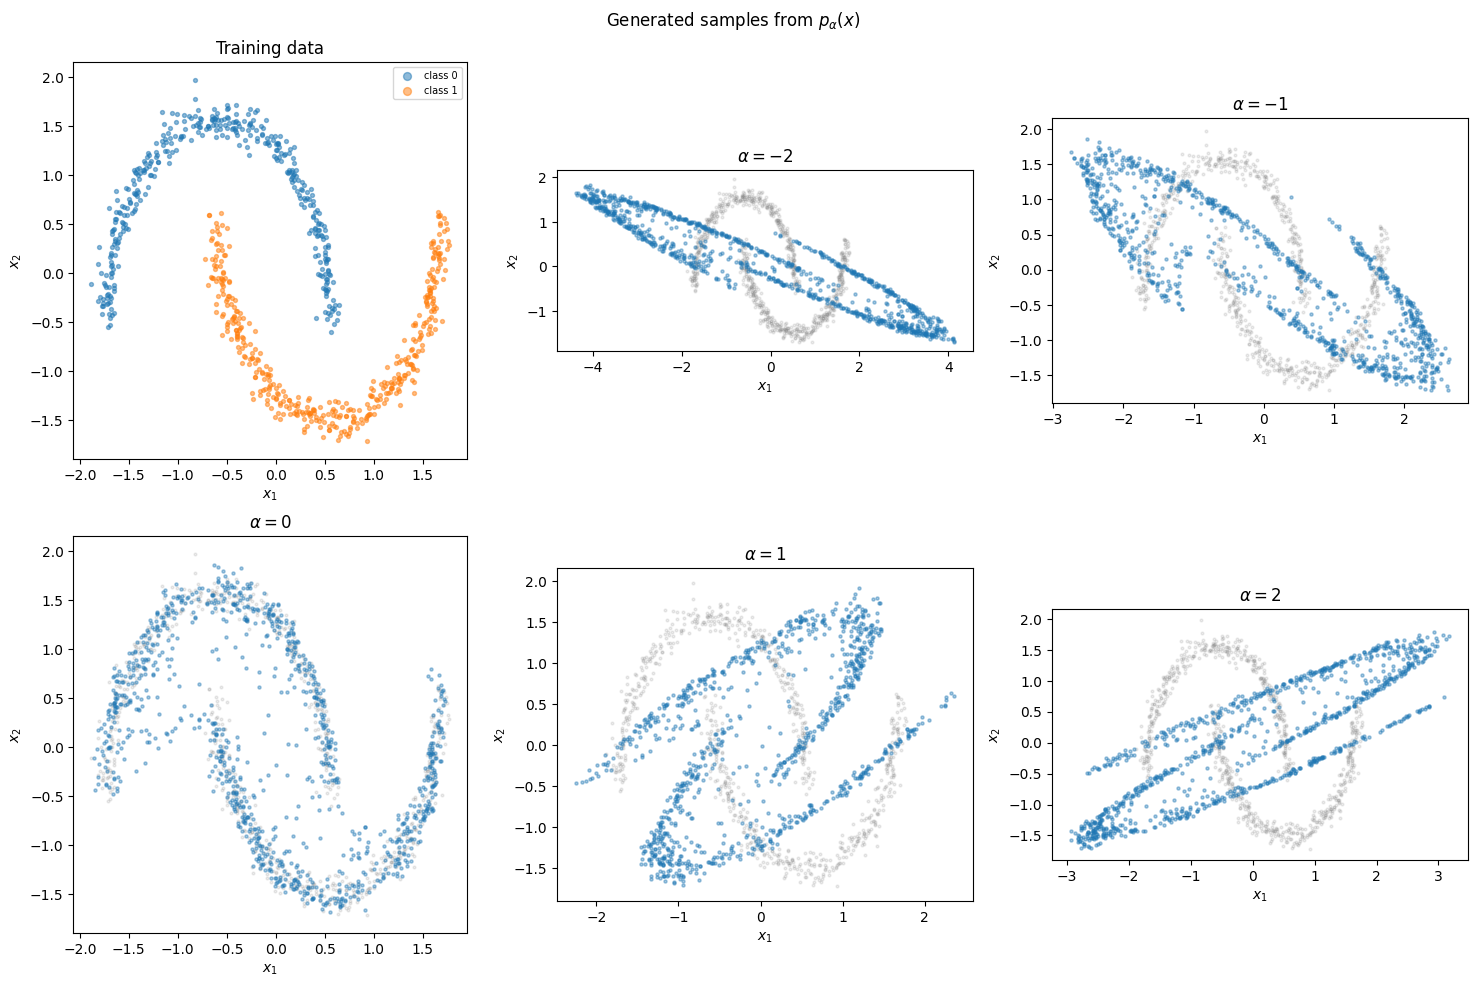

Saved figs/Figure3b.pdf


In [31]:
fig = figure3b(samples, x_train, splits.train.labels)
fig.savefig("figs/Figure3b.pdf", bbox_inches="tight")
plt.show()
print("Saved figs/Figure3b.pdf")

## Q4 - Counting FLOPs

### a)

#### Assumptions/Simplifications <span style="color: red;">Add to writeup JSON</span>

- I discount the operations used to apply the mask
- I assumed the inverse affine transformations (like exp and element-wise arithmetic) are evaluated densely across all $D$ dimensions before applying masks, rather than isolating and evaluating strictly on the $D/2$ transformed dimensions.

#### Single Coupling Layer:

**Linear(D → H): computing $h_1$**

$$h_1 = \sum_{i=1}^{D} W_{1i} \cdot x_i + b_1$$

- D multiplications ($W_{1i} \cdot x_i$)
- D-1 additions (summing the products)
- 1 addition (bias)

Total: 2D FLOPs per hidden unit

Multiply by H hidden units and B batch size: $B \cdot H \cdot 2D$

**ReLU on $h_1$**

$$h_1' = \max(0, h_1)$$

- 1 FLOP

Total across all: $B \cdot H$

**Linear(H → 2D): contribution of $h_1$ to all 2D outputs**

Each of the 2D outputs needs H multiplications, H-1 additions, and 1 bias addition = 2H FLOPs per
output.

Total: $B \cdot 2D \cdot 2H$

**So the MLP cost per coupling layer is:**

$$B \cdot (2DH + H + 4DH) = B \cdot (6DH + H) = B \cdot H(6D + 1)$$

---

**$\tanh$ scaling on $s$ (Per Layer)**

All elements of $D$-dimensional $s$ have $\tanh$ applied

Total: $B \cdot 10D$

---

**Inverse Coupling Transform (Per Layer)**

Per hidden unit:

$$h_i = (h'_i - t_i) \cdot \exp(-s_i)$$

- D subtractions ($h'_i - t_i$)
- D negations ($-s_i$)
- D exponentiations ($\exp$, 10 each)
- D multiplications

Total:
$$
B \cdot (D + D + 2 + 10D) = B \cdot 13D 
$$

---

**Log Determinant (Per Layer)**

$$\log|\det J^{-1}| = -\sum_{i=1}^{D} s_i$$

- D - 1 additions (summing the s values)
- 1 negation

Total: $B \cdot D$ per coupling layer.

---

**Base Log Density**

- $20B$

---

**Final Log Prob Summation**

$$\log p(x) = \log p(z) + \sum_{k=1}^{K} \log|\det J_k^{-1}|$$

- 1 addition of $\log p(z) + \sum_{k=1}^{K}$
- $K-1$ additions in $\sum_{k=1}^{K} \log|\det J_k^{-1}|$

Total: $B \cdot K$

---

#### Grand Total

$$
N_{\text{FLOPs}} = K(BH(6D+1)+ 10BD + 13BD + BD) + 20B + BK
$$

simplifies to

$$N_{\text{FLOPs}} = BK(H(6D+1) + 24D) + B(K + 20)$$


### b)

In [32]:
print(count_flops(dim=N_DIM, n_layers=N_LAYERS, hidden=N_HIDDEN, batch_size=BATCH_SIZE))
# TODO: Decide which flop counter to use and justify it
params_all_ones = count_flops(dim=2, n_layers=4, hidden=128, batch_size=64)
print(f"params all one count {params_all_ones}")

10979200
params all one count 439808


In [33]:
# FLOPs for the trained model's configuration
flops_full = count_flops(dim=N_DIM, n_layers=N_LAYERS, hidden=N_HIDDEN, batch_size=BATCH_SIZE)
print(f"Full model (dim={N_DIM}, K={N_LAYERS}, H={N_HIDDEN}, B={BATCH_SIZE}): {flops_full:,} FLOPs")

# Demonstrate generality across different configurations
configs = [
    {"dim": 2, "n_layers": 2, "hidden": 16,  "batch_size": 128},
    {"dim": 2, "n_layers": 4, "hidden": 64,  "batch_size": 800},
    {"dim": 2, "n_layers": 8, "hidden": 128, "batch_size": 1},
    {"dim": 10, "n_layers": 8, "hidden": 128, "batch_size": 256},
]

print("\nFLOP counts for other configurations:")
print(f"{'dim':>4}  {'K':>3}  {'H':>4}  {'B':>5}  {'FLOPs':>12}")
print("-" * 36)
for cfg in configs:
    flops = count_flops(**cfg)
    print(f"{cfg['dim']:>4}  {cfg['n_layers']:>3}  {cfg['hidden']:>4}  {cfg['batch_size']:>5}  {flops:>12,}")

Full model (dim=2, K=8, H=128, B=800): 10,979,200 FLOPs

FLOP counts for other configurations:
 dim    K     H      B         FLOPs
------------------------------------
   2    2    16    128        68,352
   2    4    64    800     2,835,200
   2    8   128      1        13,724
  10    8   128    256    16,489,472
